In [1]:
import numpy as np
import pandas as pd

### Load DataSet

In [4]:
df = pd.read_csv(
    'fra.txt',
    sep = '\t',
    usecols = [0, 1],
    names = ['English', 'French']
)

df = df.iloc[:10000]
df['French'] = df['French'].apply(lambda x: "<start>" + x + "<end>")

In [5]:
df.head()

,English,French
0,Go.,<start>Va !<end>
1,Go.,<start>Marche.<end>
2,Go.,<start>En route !<end>
3,Go.,<start>Bouge !<end>
4,Hi.,<start>Salut !<end>


### Train Test Split

In [8]:
english_sentence = df['English'].values
french_sentence = df['French'].values

### Tokenization

In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer

# English
eng_tokenizer = Tokenizer()
eng_tokenizer.fit_on_texts(english_sentence)
encoder_input = eng_tokenizer.texts_to_sequences(english_sentence)

# French
fre_tokenizer = Tokenizer(filters = '')
fre_tokenizer.fit_on_texts(french_sentence)
decoder_input = fre_tokenizer.texts_to_sequences(french_sentence)

### Add Padding

In [10]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
encoder_input = pad_sequences(encoder_input, padding='post')
decoder_input = pad_sequences(decoder_input, padding='post')

### Vocabulary Size

In [12]:
eng_vocab_size = len(eng_tokenizer.word_index)+1
fre_vocab_size = len(fre_tokenizer.word_index)+1

print("English : ", eng_vocab_size)
print("French : ", fre_vocab_size)

English :  2035
French :  5799


### Max Length

In [13]:
max_encoder = encoder_input.shape[1]
max_decoder = decoder_input.shape[1]

print("Max Encoder : ", max_encoder)
print("Max Decoder : ", max_decoder)

Max Encoder :  4
Max Decoder :  10


In [15]:
decoder_target = np.zeros_like(decoder_input)
decoder_target[:, : -1] = decoder_input[:, 1:]

### Model Archeticture

In [16]:
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Attention, Concatenate, Input, LSTM, Embedding, Dense

### Encoder Archeticture

In [17]:
# Encoder LSTM
# return_sequences=True --> Gives ALL hidden states
# return_state=True --> Gives final hidden state and cell state

In [19]:
encoder_inputs = Input(shape = (max_encoder, ))
encoder_embedding = Embedding(input_dim = eng_vocab_size, output_dim=100)(encoder_inputs)
encoder_outputs, state_h, state_c = LSTM(150, return_sequences = True, return_state = True)(encoder_embedding)

### Decoder Archeticture

In [22]:
decoder_inputs = Input(shape = (max_decoder, ))
decoder_embedding = Embedding(input_dim = fre_vocab_size, output_dim=100)(decoder_inputs)
decoder_outputs, _, _ = LSTM(150, return_sequences = True, return_state = True)(decoder_embedding)

### Attention Layer

In [23]:
attention = Attention()
attention_output = attention([decoder_outputs, encoder_outputs])

### Combine Attention + Decoder

In [26]:
context = Concatenate()([decoder_outputs, attention_output])

# Output Layer
decoder_output = Dense(fre_vocab_size, activation='softmax')(context)

### Complete Model

In [27]:
complete_model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_output
)

complete_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 10, 100)   │    579,900 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 4, 100)    │    203,500 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 10, 150), │    150,600 │ embedding_2[0][0] │
│                     │ (None, 150),      │            │                   │
│                     │ (None, 150)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 4, 150),  │    150,600 │ embedding[0][0]   │
│                     │ (None, 150),      │            │                   │
│                     │ (None, 150)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 10, 150)   │          0 │ lstm_2[0][0],     │
│ (Attention)         │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 10, 300)   │          0 │ lstm_2[0][0],     │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10, 5799)  │  1,745,499 │ concatenate_2[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,830,099 (10.80 MB)

 Trainable params: 2,830,099 (10.80 MB)

 Non-trainable params: 0 (0.00 B)

### Compilation

In [28]:
complete_model.compile(optimizer = 'adam', loss='sparse_categorical_crossentropy', metrics=['Accuracy'])

In [29]:
# Prepar Target
decoder_target = np.expand_dims(decoder_target, -1)

### Train Model

In [ ]:
history = complete_model.fit(
    [encoder_input, decoder_input],
    decoder_target,
    epochs = 15,
    batch_size = 32,
    validation_split = 0.2
)

Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 72s 260ms/step - Accuracy: 0.7683 - loss: 3.5379 - val_Accuracy: 0.7537 - val_loss: 1.8541
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 82s 260ms/step - Accuracy: 0.7869 - loss: 1.4162 - val_Accuracy: 0.7634 - val_loss: 1.8001
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 73s 223ms/step - Accuracy: 0.7973 - loss: 1.3057 - val_Accuracy: 0.7678 - val_loss: 1.7688
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 83s 225ms/step - Accuracy: 0.8127 - loss: 1.2127 - val_Accuracy: 0.7683 - val_loss: 1.7340
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 83s 229ms/step - Accuracy: 0.8285 - loss: 1.0969 - val_Accuracy: 0.7723 - val_loss: 1.7257
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 80s 222ms/step - Accuracy: 0.8331 - loss: 1.0161 - val_Accuracy: 0.7788 - val_loss: 1.7320
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 66s 155ms/step - Accuracy: 0.8413 - loss: 0.9234 - val_Accuracy: 0.7817 - val_loss: 1.7455
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 53s 211ms/step - Accuracy: 0.8500 - loss: 0

### Accuracy

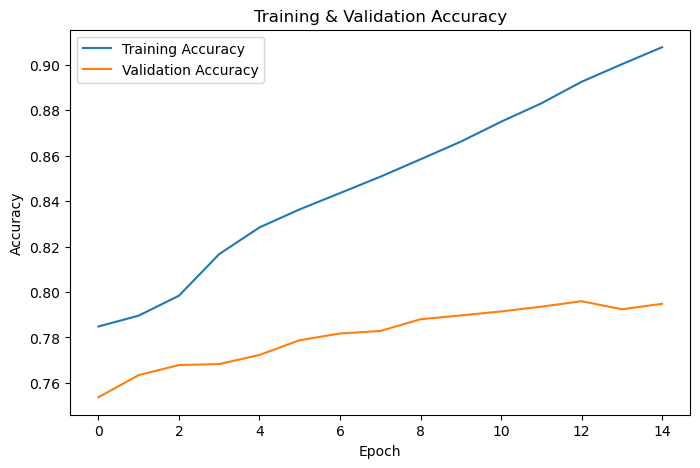

In [34]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(history.history['Accuracy'], label='Training Accuracy')
plt.plot(history.history['val_Accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.show()

### Loss

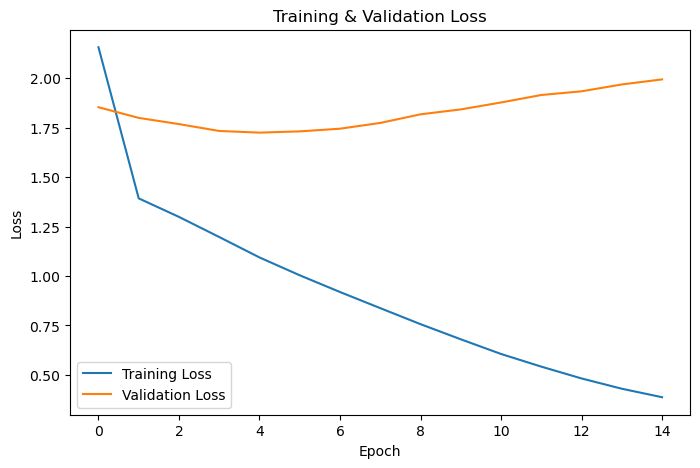

In [35]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.show()

In [ ]:
# Bahdanauf Attention

attention = Attention()
context = attention([decoder_output, encoder_output])
decoder_output = Dense(fre_vocab_size, activation='softmax')(context)

# Luong Attention

attention = Attention()
context = attention([decoder_outputs, encoder_outputs])
context = Concatenate()([decoder_outputs, context])
decoder_output = Dense(fre_vocab_size, activation='softmax')(context)